# Rule-based RQE methodology developed in Rule-Based RQE Exploration notebook applied to an unseen dataset to test performace for automatic detection of anaerobic thresholds (AnTs)

## Data Ingestion & Preprocessing 

In [126]:
#collect time, hr and rq from each subject and create dataframe to export as excel file.

import pandas as pd
import numpy as np
import os

folder_path = '/Users/adamhu/Documents/python/bhri research/hr_data'
file_list = os.listdir(folder_path)
file_list.sort()

df_all = []  # to store each subject's dataframe

def time_to_seconds(times):
    
    """Convert times (datetime or string like MM:SS or HH:MM:SS) to seconds."""
    times_seconds = []
    for t in times:
        if pd.isna(t):
            times_seconds.append(np.nan)
            continue
        try:
            # If it's a datetime object
            seconds = t.hour * 3600 + t.minute * 60 + t.second
        except AttributeError:
            # If it's a string, try parsing
            t_parsed = pd.to_datetime(str(t), format='%M:%S', errors='coerce')
            if pd.isna(t_parsed):
                t_parsed = pd.to_datetime(str(t), format='%H:%M:%S', errors='coerce')
            if pd.isna(t_parsed):
                seconds = np.nan
            else:
                seconds = t_parsed.minute * 60 + t_parsed.second + t_parsed.hour * 3600
        times_seconds.append(seconds)
    return times_seconds

for file_name in file_list:
    
    if file_name.startswith('.'):  # ignore hidden files like .DS_Store
        continue
    
    file_path = os.path.join(folder_path, file_name)
    col_id = file_name[:8]  # SUB_YYYY
    
    # Read first sheet
    temp_df = pd.read_excel(file_path, sheet_name=0)
    
    # Drop the first two rows (units + empty row)
    times = temp_df['t'].drop([0,1]).reset_index(drop=True)
    rq = temp_df['RQ'].drop([0,1]).reset_index(drop=True)
    hr = temp_df['HR'].drop([0,1]).reset_index(drop=True)
    
    # Convert time
    times_sec = time_to_seconds(times)
    
    # Build dataframe with subject-specific column names
    subj_df = pd.DataFrame({
        f"t_{col_id}": times_sec,
        f"rq_{col_id}": rq.values,
        f"hr_{col_id}": hr.values
    })
    
    df_all.append(subj_df)

# Concatenate all subjects side by side
df_final = pd.concat(df_all, axis=1)

# Save to Excel
#df_final.to_excel("aggregated_hr_data.xlsx", index=False)

print(df_final)

     t_001_2024 rq_001_2024 hr_001_2024  t_001_2025 rq_001_2025 hr_001_2025  \
0           3.0        0.81          86         7.0        0.81         102   
1           6.0        0.78          89        11.0        0.76         106   
2          11.0        0.79          99        13.0        0.74         106   
3          17.0        0.83         106        16.0        0.77         108   
4          22.0        0.85         110        20.0        0.83         111   
..          ...         ...         ...         ...         ...         ...   
818         NaN         NaN         NaN         NaN         NaN         NaN   
819         NaN         NaN         NaN         NaN         NaN         NaN   
820         NaN         NaN         NaN         NaN         NaN         NaN   
821         NaN         NaN         NaN         NaN         NaN         NaN   
822         NaN         NaN         NaN         NaN         NaN         NaN   

     t_002_2024 rq_002_2024 hr_002_2024  t_002_2025

In [150]:
lastyear = 0
thisyear = 0

for file in file_list:

    if file.startswith('.'):
        continue 

    elif file[4:8] == '2024':
        lastyear += 1

    elif file[4:8] == '2025':
        thisyear += 1

print(f'There are {lastyear} exercise tests from 2024 and {thisyear} exercise tests from 2025 in this data set of n = {lastyear + thisyear}.')

There are 23 exercise tests from 2024 and 26 exercise tests from 2025 in this data set of n = 49.


In [1]:
import pandas as pd 
import numpy as np

file = '/Users/adamhu/documents/python/bhri research/aggregated_hr_data.csv'

df = pd.read_csv(file)
df.columns
print(df.head())

   t_001_2024  rq_001_2024  hr_001_2024  t_001_2025  rq_001_2025  hr_001_2025  \
0         3.0         0.81         86.0         7.0         0.81        102.0   
1         6.0         0.78         89.0        11.0         0.76        106.0   
2        11.0         0.79         99.0        13.0         0.74        106.0   
3        17.0         0.83        106.0        16.0         0.77        108.0   
4        22.0         0.85        110.0        20.0         0.83        111.0   

   t_002_2024  rq_002_2024  hr_002_2024  t_002_2025  ...  hr_024_2025  \
0         2.0         0.91        108.0         2.0  ...        122.0   
1         5.0         0.93        109.0         3.0  ...        122.0   
2         8.0         0.98        114.0         6.0  ...        124.0   
3        11.0         0.97        124.0         8.0  ...        127.0   
4        14.0         0.95        128.0        10.0  ...        127.0   

   t_025_2024  rq_025_2024  hr_025_2024  t_025_2025  rq_025_2025  hr_025_2

### Linear Interpolation

In [179]:
import pandas as pd
import numpy as np

# Step 1: Initialize the new DataFrame with 't' from 1 to 850
new_df = pd.DataFrame({'t': range(1, 850)})

# Step 2: Loop through each subject to interpolate and add their 'rq' and 'hr' columns
for i in range(0, int(len(df.columns) / 3)):

    temp_identifier = df.columns[i * 3]
    identifier = temp_identifier[2:]
    
    # Define the column names for each subject in the original DataFrame
    rq_column = f'rq_{identifier}'
    hr_column = f'hr_{identifier}'

    # Extract the original 'rq' and 'hr' series for the current subject
    rq_series = df[rq_column]
    hr_series = df[hr_column]

    # Create a temporary DataFrame for reindexing and interpolation
    temp_df = pd.DataFrame({
        't': df[f't_{identifier}'],
        rq_column: rq_series,
        hr_column: hr_series
    })
    
    # Remove any duplicate time entries in 't'
    temp_df = temp_df.drop_duplicates(subset='t').set_index('t')

    # Reindex to create the full range from 1 to 800 with a 1-second interval
    temp_df = temp_df.reindex(new_df['t'], method=None)

    # Interpolate missing values in 'rq' and 'hr' columns
    temp_df = temp_df.interpolate(method='linear')

    # Add interpolated columns to new_df in the required order
    new_df[f'rq_{identifier}'] = temp_df[rq_column].values
    new_df[f'hr_{identifier}'] = temp_df[hr_column].values

# Use backfill to fill in only the early NaNs for each column
new_df = new_df.bfill()

# Convert all 'hr' columns to integers
hr_columns = [col for col in new_df.columns if col.startswith('hr_')]
new_df[hr_columns] = new_df[hr_columns].astype(int)

# Round all 'rq' columns to two decimal places
rq_columns = [col for col in new_df.columns if col.startswith('rq_')]
new_df[rq_columns] = new_df[rq_columns].round(2)

# Display the head of the new DataFrame to verify
print(new_df.head())

   t  rq_001_2024  hr_001_2024  rq_001_2025  hr_001_2025  rq_002_2024  \
0  1         0.81           86         0.81          102         0.91   
1  2         0.81           86         0.81          102         0.91   
2  3         0.81           86         0.81          102         0.92   
3  4         0.80           87         0.81          102         0.92   
4  5         0.79           88         0.81          102         0.93   

   hr_002_2024  rq_002_2025  hr_002_2025  rq_003_2024  ...  rq_024_2024  \
0          108         0.76           60          0.8  ...         0.81   
1          108         0.76           60          0.8  ...         0.81   
2          108         0.79           60          0.8  ...         0.81   
3          108         0.79           61          0.8  ...         0.76   
4          109         0.80           63          0.8  ...         0.77   

   hr_024_2024  rq_024_2025  hr_024_2025  rq_025_2024  hr_025_2024  \
0          101         0.82          122

### Ground truth anaerobic threshold definition

In [167]:
# Anaerobic threshold times in seconds for each subject in order 
AT_secs = [ 

    195, 105, 283, 82, 320, 335, 391, 422, 473, 358, 521, 379, 
    303, 331, 202, 413, 341, 498, 386, 364, 288, 355, 0, 467, 355, 
    442, 455, 296, 225, 420, 286, 336, 298, 349, 315, 471, 301, 358, 
    494, 107, 425, 411, 302, 302, 385, 284, 270, 532, 375
    
]

print(AT_secs)

[195, 105, 283, 82, 320, 335, 391, 422, 473, 358, 521, 379, 303, 331, 202, 413, 341, 498, 386, 364, 288, 355, 0, 467, 355, 442, 455, 296, 225, 420, 286, 336, 298, 349, 315, 471, 301, 358, 494, 107, 425, 411, 302, 302, 385, 284, 270, 532, 375]


## Application of RQE with optimised search window applied to 2025 data

In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from pyrqa.time_series import TimeSeries
from pyrqa.settings import Settings
from pyrqa.computation import RQAComputation
from pyrqa.neighbourhood import FixedRadius

# Define parameters
time_interval = 1
epoch_length = 125
step_size = 1
embedding_dim = 7
time_delay = 1
radius = 5
min_diag_line_length = 4

# List to collect results for each subject
results = []

# Loop over each subject to calculate determinism and its second derivative within the specified range
for i in range(0, 49):

    index = 1 + (i * 2)
    temp_identifier = new_df.columns[index]
    identifier = temp_identifier[3:]
    print(identifier)
    year = identifier[4:8]
    print(year)

    if year == '2024': #only take subjects from 2025 
        continue 

    elif year == '2025':  
    
        # Define time, heart rate, and AT time
        time = new_df['t'].values
        heart_rate = new_df[f'hr_{identifier}'].values
        at_time = AT_secs[i]

        # Determine the maximum heart rate for this subject and the time when it occurs
        max_hr = np.max(heart_rate)
        max_hr_time = time[np.argmax(heart_rate)]

        # Exclude heart rate data before 30 seconds and after the maximum heart rate time
        filtered_indices = (time >= 30) & (time <= max_hr_time)
        filtered_time = time[filtered_indices]
        filtered_hr = heart_rate[filtered_indices]

        # Interpolation for evenly spaced time intervals
        interpolator = interp1d(filtered_time, filtered_hr, kind='linear', fill_value="extrapolate")
        regular_times = np.arange(filtered_time.min(), filtered_time.max(), time_interval)
        interpolated_hr = interpolator(regular_times)

        # Ensure we have enough data to proceed
        if len(interpolated_hr) < epoch_length:
            print(f"Not enough data for Subject {subject} in the specified range. Skipping.")
            continue

        # Calculate determinism over epochs within the filtered range
        determinism = []
        time_points = []

        for start in range(0, len(interpolated_hr) - epoch_length + 1, step_size):
            segment = interpolated_hr[start:start + epoch_length]
            time_series = TimeSeries(segment)
        
            # Set RQA settings
            settings = Settings(time_series, neighbourhood=FixedRadius(radius))
        
            rqa_computation = RQAComputation.create(settings)
            rqa_computation.min_diagonal_line_length = 1
            rqa_result = rqa_computation.run()
            rqa_result.min_diagonal_line_length = min_diag_line_length
        
            # Extract determinism
            det = rqa_result.determinism
            determinism.append(det * 100)
            time_points.append(start + (epoch_length // 2) + 30)  # Offset time points to align with the start at 30s

        # Convert to numpy arrays for further analysis
        determinism = np.array(determinism)
        time_points = np.array(time_points)
        lower_bound = 0.6 * max_hr_time
        upper_bound = 0.85 * max_hr_time

        # Calculate second derivative of determinism if enough points
        if len(time_points) > 2:
            first_derivative = np.diff(determinism) / np.diff(time_points)
            time_intervals_1 = (time_points[2:] - time_points[:-2]) / 2
            second_derivative = (first_derivative[1:] - first_derivative[:-1]) / time_intervals_1

            if len(second_derivative) > 0: # Ensure second_derivative is non-empty before finding convex minima
                sorted_minima_indices = np.argsort(second_derivative) # Sort minima indices in ascending order of convexity
    
                # Iterate through the sorted indices to find the first convex minimum within expected range
                convex_minima_time = np.nan  # Default if no valid minima is found
                for idx in sorted_minima_indices:
                    candidate_time = time_points[2:][idx]
        
                    # Check if the candidate is within range 
                    if lower_bound <= candidate_time <= upper_bound: 
                        convex_minima_time = candidate_time
                        break
                    else:
                        convex_minima_time = np.nan
    
            else:
                print(f"No convex minima found for Subject {subject}.")
                convex_minima_time = np.nan

        else:
            print(f"Not enough data points after filtering for second derivative for Subject {subject}.")
            convex_minima_time = np.nan

        # Store the results
        results.append({
            'Subject': identifier,
            'AT_time': at_time,
            'Convex_Minima_Time': convex_minima_time
        })

001_2024
2024
001_2025
2025
002_2024
2024
002_2025
2025
003_2024
2024
003_2025
2025
004_2024
2024
004_2025
2025
005_2024
2024
005_2025
2025
006_2024
2024
006_2025
2025
007_2024
2024
007_2025
2025
008_2024
2024
008_2025
2025
009_2025
2025
010_2024
2024
010_2025
2025
011_2025
2025
012_2024
2024
012_2025
2025
013_2024
2024
013_2025
2025
014_2024
2024
014_2025
2025
015_2024
2024
015_2025
2025
016_2024
2024
016_2025
2025
017_2024
2024
017_2025
2025
018_2024
2024
018_2025
2025
019_2024
2024
019_2025
2025
020_2024
2024
020_2025
2025
021_2024
2024
021_2025
2025
022_2024
2024
022_2025
2025
023_2024
2024
023_2025
2025
024_2024
2024
024_2025
2025
025_2024
2024
025_2025
2025
026_2025
2025


### Plot results
Transition from Pearson and Spearman coefficients as evaluation metrics during exploratory phases towards mean absolute error (MAE) and median absolute error (MedAE) as the primary performance metrics due to their clinical relevance and improved robustness.

Also include a histogram showing the distribution of the absolute error.

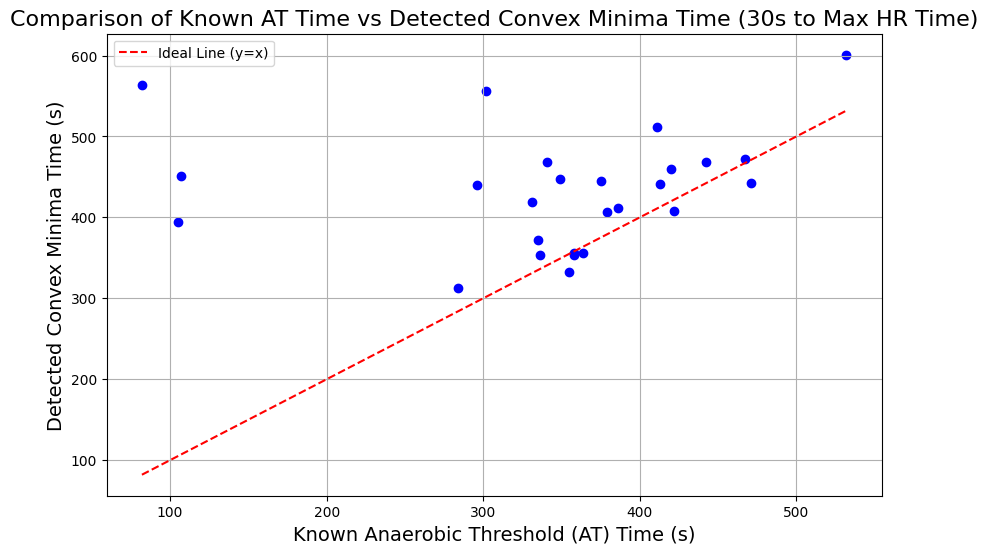

     Subject  AT_time  Convex_Minima_Time
0   001_2025    105.0               394.0
1   002_2025     82.0               563.0
2   003_2025    335.0               372.0
3   004_2025    422.0               408.0
4   005_2025    358.0               356.0
5   006_2025    379.0               407.0
6   007_2025    331.0               419.0
7   008_2025    413.0               441.0
8   009_2025    341.0               468.0
9   010_2025    386.0               412.0
10  011_2025    364.0               356.0
11  012_2025    355.0               333.0
12  013_2025    467.0               472.0
13  014_2025    442.0               469.0
14  015_2025    296.0               440.0
15  016_2025    420.0               460.0
16  017_2025    336.0               353.0
17  018_2025    349.0               447.0
18  019_2025    471.0               443.0
19  020_2025    358.0               353.0
20  021_2025    107.0               451.0
21  022_2025    411.0               512.0
22  023_2025    302.0             

In [169]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df['AT_time'] = results_df['AT_time'].astype(float)
results_df['Convex_Minima_Time'] = results_df['Convex_Minima_Time'].astype(float)

# Scatterplot of Convex Minima Time vs Known AT Time
plt.figure(figsize=(10, 6))
plt.scatter(results_df['AT_time'], results_df['Convex_Minima_Time'], color='blue')
plt.plot([results_df['AT_time'].min(), results_df['AT_time'].max()],
         [results_df['AT_time'].min(), results_df['AT_time'].max()],
         color='red', linestyle='--', label='Ideal Line (y=x)')
plt.xlabel('Known Anaerobic Threshold (AT) Time (s)', fontsize=14)
plt.ylabel('Detected Convex Minima Time (s)', fontsize=14)
plt.title('Comparison of Known AT Time vs Detected Convex Minima Time (30s to Max HR Time)', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Display the results
print(results_df)

     Subject  AT_time  Convex_Minima_Time
0   001_2025    105.0               394.0
1   002_2025     82.0               563.0
2   003_2025    335.0               372.0
3   004_2025    422.0               408.0
4   005_2025    358.0               356.0
5   006_2025    379.0               407.0
6   007_2025    331.0               419.0
7   008_2025    413.0               441.0
8   009_2025    341.0               468.0
9   010_2025    386.0               412.0
10  011_2025    364.0               356.0
11  012_2025    355.0               333.0
12  013_2025    467.0               472.0
13  014_2025    442.0               469.0
14  015_2025    296.0               440.0
15  016_2025    420.0               460.0
16  017_2025    336.0               353.0
17  018_2025    349.0               447.0
18  019_2025    471.0               443.0
19  020_2025    358.0               353.0
20  021_2025    107.0               451.0
21  022_2025    411.0               512.0
22  023_2025    302.0             

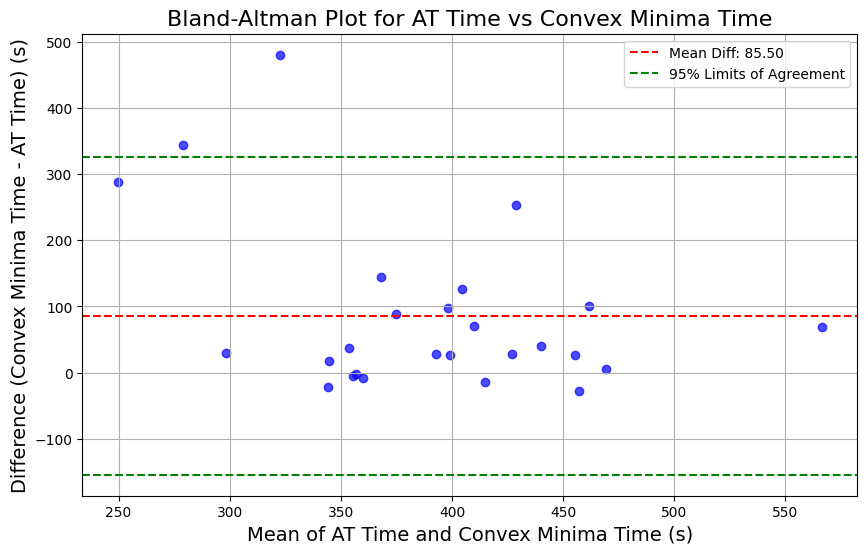

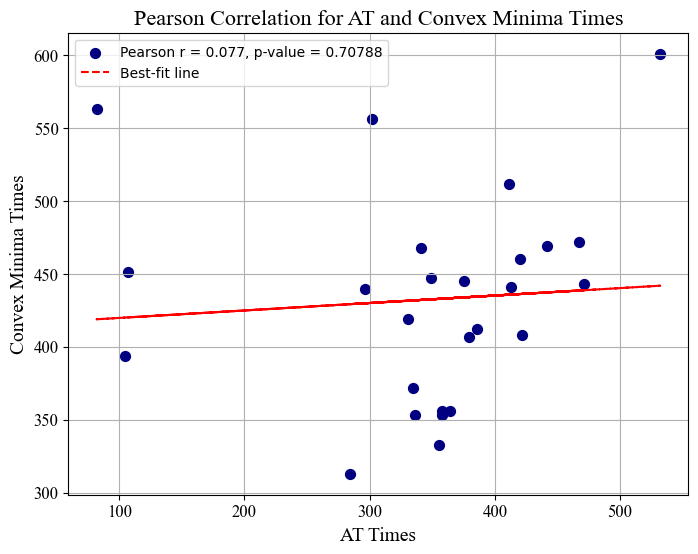

[289.0, 481.0, 37.0, 14.0, 2.0, 28.0, 88.0, 28.0, 127.0, 26.0, 8.0, 22.0, 5.0, 27.0, 144.0, 40.0, 17.0, 98.0, 28.0, 5.0, 344.0, 101.0, 254.0, 29.0, 69.0, 70.0]


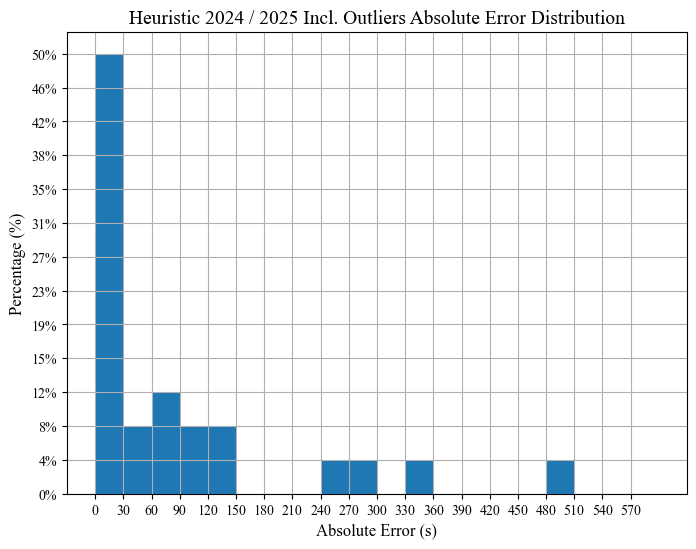

In [170]:
#no subjects excluded

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, median_absolute_error

# Exclude outliers 
exclude_ids = []
filtered_results = results_df[~results_df['Subject'].isin(exclude_ids)].dropna(subset=['AT_time', 'Convex_Minima_Time'])
print(filtered_results)

# Calculate correlation between AT_time and Convex_Minima_Time
pearson_corr, pearson_p = pearsonr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
spearman_corr, spearman_p = spearmanr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
MAE, MedAE = mean_absolute_error(filtered_results['AT_time'], filtered_results['Convex_Minima_Time']), median_absolute_error(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])

print(f"Pearson Correlation: {pearson_corr:.3f}, p-value: {pearson_p:.5f}")
print(f"Spearman Correlation: {spearman_corr:.3f}, p-value: {spearman_p:.5f}")
print(f'MAE: {MAE}, MedAE: {MedAE}')

# Bland-Altman Plot
# Calculate means and differences
mean_times = (filtered_results['AT_time'] + filtered_results['Convex_Minima_Time']) / 2
diff_times = filtered_results['Convex_Minima_Time'] - filtered_results['AT_time']

# Calculate mean and standard deviation of differences
mean_diff = np.mean(diff_times)
std_diff = np.std(diff_times)

# Create Bland-Altman plot
plt.figure(figsize=(10, 6))
plt.scatter(mean_times, diff_times, color='blue', alpha=0.7)
plt.axhline(mean_diff, color='red', linestyle='--', label=f'Mean Diff: {mean_diff:.2f}')
plt.axhline(mean_diff + 1.96 * std_diff, color='green', linestyle='--', label='95% Limits of Agreement')
plt.axhline(mean_diff - 1.96 * std_diff, color='green', linestyle='--')
plt.xlabel('Mean of AT Time and Convex Minima Time (s)', fontsize=14)
plt.ylabel('Difference (Convex Minima Time - AT Time) (s)', fontsize=14)
plt.title('Bland-Altman Plot for AT Time vs Convex Minima Time', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Create scatter plot
tnrfont = {'fontname':'Times New Roman'}
plt.figure(figsize=(8, 6))
plt.scatter(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], color='navy', s=50, label=f'Pearson r = {pearson_corr:.3f}, p-value = {pearson_p:.5f}')

# Calculate and plot the line of best fit
m, b = np.polyfit(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], 1)
plt.plot(filtered_results['AT_time'], m*filtered_results['AT_time'] + b, color='red', linestyle='--', label='Best-fit line')

# Add labels and title
plt.xlabel('AT Times', fontsize = 14, **tnrfont)
plt.xticks(fontsize = 12, **tnrfont)
plt.ylabel('Convex Minima Times', fontsize = 14, **tnrfont)
plt.yticks(fontsize = 12, **tnrfont)
plt.title('Pearson Correlation for AT and Convex Minima Times', fontsize = 16, **tnrfont)
plt.legend()
plt.grid(True)
plt.show()

#create histrogram distribution of absolute error distribution 
from matplotlib.ticker import PercentFormatter

abs_error = list(abs(filtered_results['AT_time'] - filtered_results['Convex_Minima_Time']))
print(abs_error)
n_bins = 20

plt.figure(figsize = (8, 6))
bin_edges = np.linspace(0, 600, n_bins+1)

plt.hist(abs_error, bins = bin_edges, weights = np.ones(len(abs_error)) / len(abs_error), color = 'blue')

plt.xlabel('Absolute Error (s)', fontsize = 12, **tnrfont)
plt.xticks(np.arange(0, 600, step = 600/n_bins), np.arange(0, 600, step = 600/n_bins, dtype = int), fontsize=10, **tnrfont)

N = len(abs_error)  # number of samples
counts, bins, patches = plt.hist(
    abs_error, bins=bin_edges,
    weights=np.ones(N) / N
)

# Step size = one subject = 1/N
step = 1 / N

# Round max_height up to the nearest multiple of step
max_height = max(counts)
max_height_rounded = np.ceil(max_height / step) * step

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

# Ticks at multiples of step (1 subject = step)
plt.yticks(
    np.arange(0, max_height_rounded + step, step),
    fontsize=10, **tnrfont
)

plt.ylabel('Percentage (%)', fontsize = 12, **tnrfont)

plt.title('Heuristic 2024 / 2025 Incl. Outliers Absolute Error Distribution', fontsize = 14, **tnrfont)
plt.grid(True)
plt.show()

     Subject  AT_time  Convex_Minima_Time
2   003_2025    335.0               372.0
3   004_2025    422.0               408.0
4   005_2025    358.0               356.0
5   006_2025    379.0               407.0
6   007_2025    331.0               419.0
7   008_2025    413.0               441.0
8   009_2025    341.0               468.0
9   010_2025    386.0               412.0
10  011_2025    364.0               356.0
11  012_2025    355.0               333.0
12  013_2025    467.0               472.0
13  014_2025    442.0               469.0
14  015_2025    296.0               440.0
15  016_2025    420.0               460.0
16  017_2025    336.0               353.0
17  018_2025    349.0               447.0
18  019_2025    471.0               443.0
19  020_2025    358.0               353.0
21  022_2025    411.0               512.0
22  023_2025    302.0               556.0
23  024_2025    284.0               313.0
24  025_2025    532.0               601.0
25  026_2025    375.0             

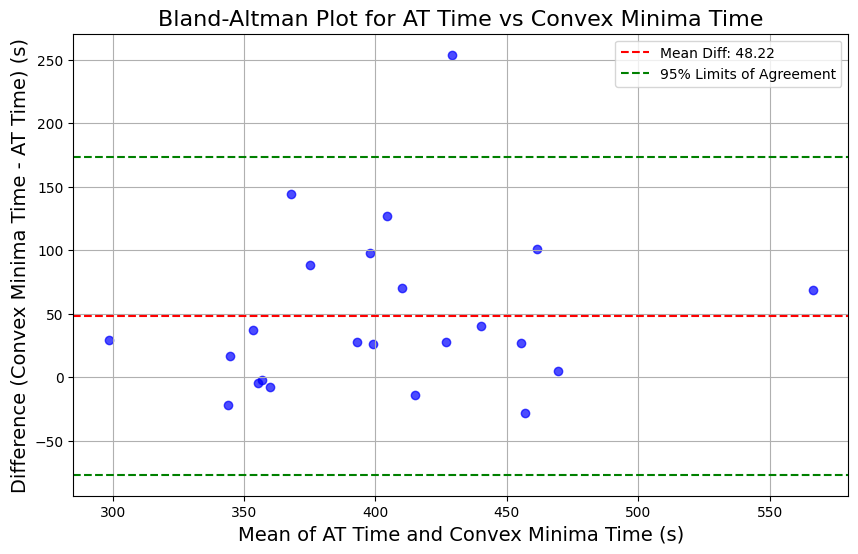

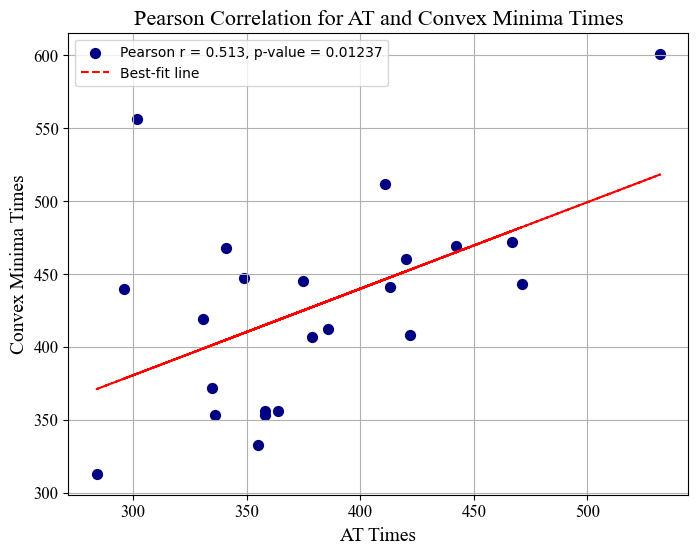

[37.0, 14.0, 2.0, 28.0, 88.0, 28.0, 127.0, 26.0, 8.0, 22.0, 5.0, 27.0, 144.0, 40.0, 17.0, 98.0, 28.0, 5.0, 101.0, 254.0, 29.0, 69.0, 70.0]


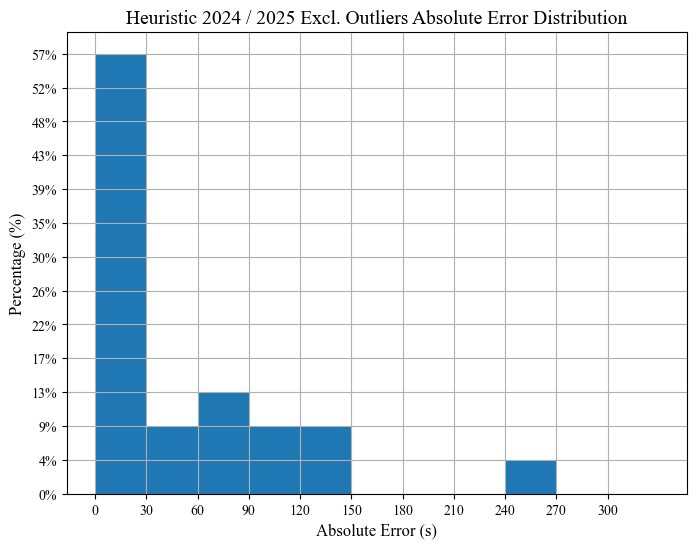

In [172]:
#outliers excluded (3 early LT outliers)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Exclude outliers 
exclude_ids = ['001_2025', '002_2025', '021_2025']
filtered_results = results_df[~results_df['Subject'].isin(exclude_ids)].dropna(subset=['AT_time', 'Convex_Minima_Time'])
print(filtered_results)

# Calculate correlation between AT_time and Convex_Minima_Time
pearson_corr, pearson_p = pearsonr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
spearman_corr, spearman_p = spearmanr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
MAE, MedAE = mean_absolute_error(filtered_results['AT_time'], filtered_results['Convex_Minima_Time']), median_absolute_error(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])

print(f"Pearson Correlation: {pearson_corr:.3f}, p-value: {pearson_p:.5f}")
print(f"Spearman Correlation: {spearman_corr:.3f}, p-value: {spearman_p:.5f}")
print(f'MAE: {MAE}, MedAE: {MedAE}')

# Bland-Altman Plot
# Calculate means and differences
mean_times = (filtered_results['AT_time'] + filtered_results['Convex_Minima_Time']) / 2
diff_times = filtered_results['Convex_Minima_Time'] - filtered_results['AT_time']

# Calculate mean and standard deviation of differences
mean_diff = np.mean(diff_times)
std_diff = np.std(diff_times)

# Create Bland-Altman plot
plt.figure(figsize=(10, 6))
plt.scatter(mean_times, diff_times, color='blue', alpha=0.7)
plt.axhline(mean_diff, color='red', linestyle='--', label=f'Mean Diff: {mean_diff:.2f}')
plt.axhline(mean_diff + 1.96 * std_diff, color='green', linestyle='--', label='95% Limits of Agreement')
plt.axhline(mean_diff - 1.96 * std_diff, color='green', linestyle='--')
plt.xlabel('Mean of AT Time and Convex Minima Time (s)', fontsize=14)
plt.ylabel('Difference (Convex Minima Time - AT Time) (s)', fontsize=14)
plt.title('Bland-Altman Plot for AT Time vs Convex Minima Time', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Create scatter plot
tnrfont = {'fontname':'Times New Roman'}
plt.figure(figsize=(8, 6))
plt.scatter(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], color='navy', s=50, label=f'Pearson r = {pearson_corr:.3f}, p-value = {pearson_p:.5f}')

# Calculate and plot the line of best fit
m, b = np.polyfit(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], 1)
plt.plot(filtered_results['AT_time'], m*filtered_results['AT_time'] + b, color='red', linestyle='--', label='Best-fit line')

# Add labels and title
plt.xlabel('AT Times', fontsize = 14, **tnrfont)
plt.xticks(fontsize = 12, **tnrfont)
plt.ylabel('Convex Minima Times', fontsize = 14, **tnrfont)
plt.yticks(fontsize = 12, **tnrfont)
plt.title('Pearson Correlation for AT and Convex Minima Times', fontsize = 16, **tnrfont)
plt.legend()
plt.grid(True)
plt.show()

#create histrogram distribution of absolute error distribution 
from matplotlib.ticker import PercentFormatter

abs_error = list(abs(filtered_results['AT_time'] - filtered_results['Convex_Minima_Time']))
print(abs_error)
n_bins = 11

plt.figure(figsize = (8, 6))
bin_edges = np.linspace(0, 330, n_bins+1)

plt.hist(abs_error, bins = bin_edges, weights = np.ones(len(abs_error)) / len(abs_error), color = 'blue')

plt.xlabel('Absolute Error (s)', fontsize = 12, **tnrfont)
plt.xticks(np.arange(0, 330, step = 330/n_bins), np.arange(0, 330, step = 330/n_bins, dtype = int), fontsize=10, **tnrfont)

N = len(abs_error)  # number of samples
counts, bins, patches = plt.hist(
    abs_error, bins=bin_edges,
    weights=np.ones(N) / N
)

# Step size = one subject = 1/N
step = 1 / N

# Round max_height up to the nearest multiple of step
max_height = max(counts)
max_height_rounded = np.ceil(max_height / step) * step

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

# Ticks at multiples of step (1 subject = step)
plt.yticks(
    np.arange(0, max_height_rounded + step, step),
    fontsize=10, **tnrfont
)

plt.ylabel('Percentage (%)', fontsize = 12, **tnrfont)

plt.title('Heuristic 2024 / 2025 Excl. Outliers Absolute Error Distribution', fontsize = 14, **tnrfont)
plt.grid(True)
plt.show()

     Subject  AT_time  Convex_Minima_Time
2   003_2025    335.0               372.0
3   004_2025    422.0               408.0
4   005_2025    358.0               356.0
5   006_2025    379.0               407.0
6   007_2025    331.0               419.0
7   008_2025    413.0               441.0
8   009_2025    341.0               468.0
9   010_2025    386.0               412.0
10  011_2025    364.0               356.0
11  012_2025    355.0               333.0
12  013_2025    467.0               472.0
13  014_2025    442.0               469.0
14  015_2025    296.0               440.0
15  016_2025    420.0               460.0
16  017_2025    336.0               353.0
17  018_2025    349.0               447.0
18  019_2025    471.0               443.0
19  020_2025    358.0               353.0
21  022_2025    411.0               512.0
23  024_2025    284.0               313.0
24  025_2025    532.0               601.0
25  026_2025    375.0               445.0
Pearson Correlation: 0.707, p-valu

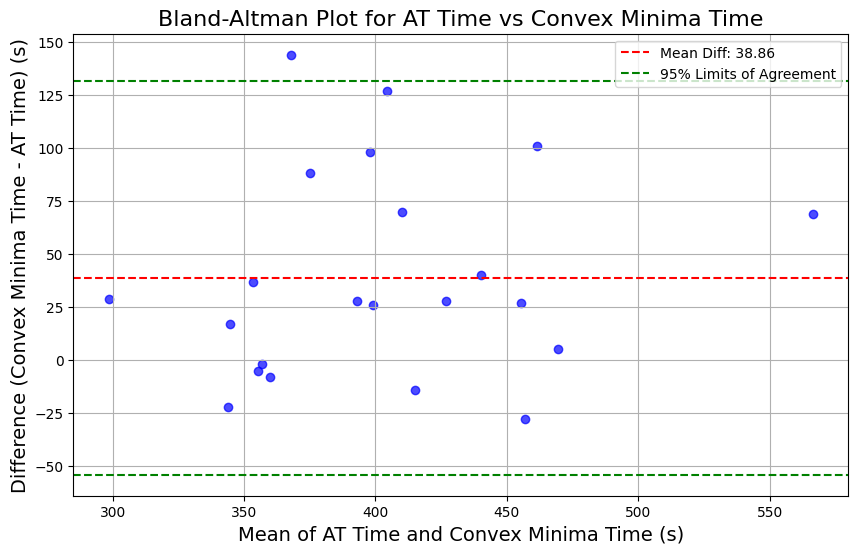

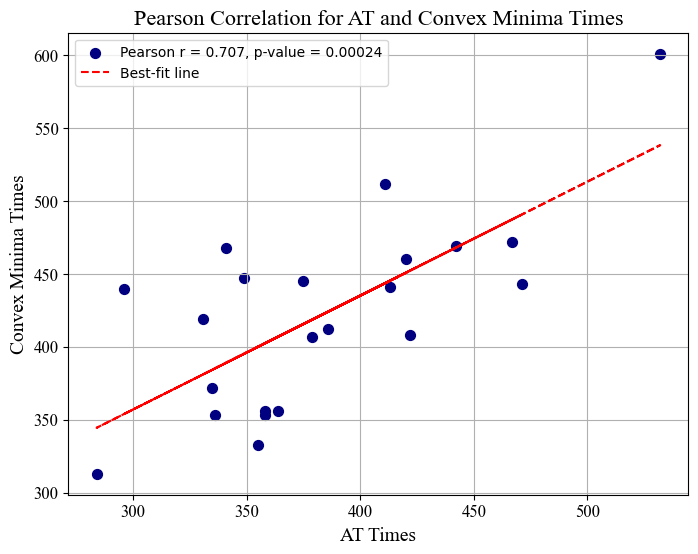

[37.0, 14.0, 2.0, 28.0, 88.0, 28.0, 127.0, 26.0, 8.0, 22.0, 5.0, 27.0, 144.0, 40.0, 17.0, 98.0, 28.0, 5.0, 101.0, 29.0, 69.0, 70.0]


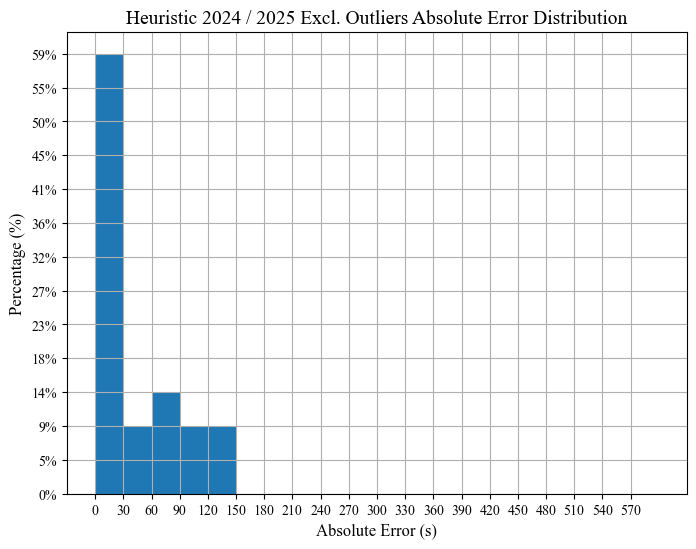

In [173]:
#outliers excluded (3 early LT outliers + 1 outlier)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Exclude outliers 
exclude_ids = ['001_2025', '002_2025', '021_2025', '023_2025']
filtered_results = results_df[~results_df['Subject'].isin(exclude_ids)].dropna(subset=['AT_time', 'Convex_Minima_Time'])
print(filtered_results)

# Calculate correlation between AT_time and Convex_Minima_Time
pearson_corr, pearson_p = pearsonr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
spearman_corr, spearman_p = spearmanr(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])
MAE, MedAE = mean_absolute_error(filtered_results['AT_time'], filtered_results['Convex_Minima_Time']), median_absolute_error(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'])

print(f"Pearson Correlation: {pearson_corr:.3f}, p-value: {pearson_p:.5f}")
print(f"Spearman Correlation: {spearman_corr:.3f}, p-value: {spearman_p:.5f}")
print(f'MAE: {MAE}, MedAE: {MedAE}')

# Bland-Altman Plot
# Calculate means and differences
mean_times = (filtered_results['AT_time'] + filtered_results['Convex_Minima_Time']) / 2
diff_times = filtered_results['Convex_Minima_Time'] - filtered_results['AT_time']

# Calculate mean and standard deviation of differences
mean_diff = np.mean(diff_times)
std_diff = np.std(diff_times)

# Create Bland-Altman plot
plt.figure(figsize=(10, 6))
plt.scatter(mean_times, diff_times, color='blue', alpha=0.7)
plt.axhline(mean_diff, color='red', linestyle='--', label=f'Mean Diff: {mean_diff:.2f}')
plt.axhline(mean_diff + 1.96 * std_diff, color='green', linestyle='--', label='95% Limits of Agreement')
plt.axhline(mean_diff - 1.96 * std_diff, color='green', linestyle='--')
plt.xlabel('Mean of AT Time and Convex Minima Time (s)', fontsize=14)
plt.ylabel('Difference (Convex Minima Time - AT Time) (s)', fontsize=14)
plt.title('Bland-Altman Plot for AT Time vs Convex Minima Time', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Create scatter plot
tnrfont = {'fontname':'Times New Roman'}
plt.figure(figsize=(8, 6))
plt.scatter(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], color='navy', s=50, label=f'Pearson r = {pearson_corr:.3f}, p-value = {pearson_p:.5f}')

# Calculate and plot the line of best fit
m, b = np.polyfit(filtered_results['AT_time'], filtered_results['Convex_Minima_Time'], 1)
plt.plot(filtered_results['AT_time'], m*filtered_results['AT_time'] + b, color='red', linestyle='--', label='Best-fit line')

# Add labels and title
plt.xlabel('AT Times', fontsize = 14, **tnrfont)
plt.xticks(fontsize = 12, **tnrfont)
plt.ylabel('Convex Minima Times', fontsize = 14, **tnrfont)
plt.yticks(fontsize = 12, **tnrfont)
plt.title('Pearson Correlation for AT and Convex Minima Times', fontsize = 16, **tnrfont)
plt.legend()
plt.grid(True)
plt.show()

#create histrogram distribution of absolute error distribution 
from matplotlib.ticker import PercentFormatter

abs_error = list(abs(filtered_results['AT_time'] - filtered_results['Convex_Minima_Time']))
print(abs_error)
n_bins = 20

plt.figure(figsize = (8, 6))
bin_edges = np.linspace(0, 600, n_bins+1)

plt.hist(abs_error, bins = bin_edges, weights = np.ones(len(abs_error)) / len(abs_error), color = 'blue')

plt.xlabel('Absolute Error (s)', fontsize = 12, **tnrfont)
plt.xticks(np.arange(0, 600, step = 600/n_bins), np.arange(0, 600, step = 600/n_bins, dtype = int), fontsize=10, **tnrfont)

N = len(abs_error)  # number of samples
counts, bins, patches = plt.hist(
    abs_error, bins=bin_edges,
    weights=np.ones(N) / N
)

# Step size = one subject = 1/N
step = 1 / N

# Round max_height up to the nearest multiple of step
max_height = max(counts)
max_height_rounded = np.ceil(max_height / step) * step

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

# Ticks at multiples of step (1 subject = step)
plt.yticks(
    np.arange(0, max_height_rounded + step, step),
    fontsize=10, **tnrfont
)

plt.ylabel('Percentage (%)', fontsize = 12, **tnrfont)

plt.title('Heuristic 2024 / 2025 Excl. Outliers Absolute Error Distribution', fontsize = 14, **tnrfont)
plt.grid(True)
plt.show()

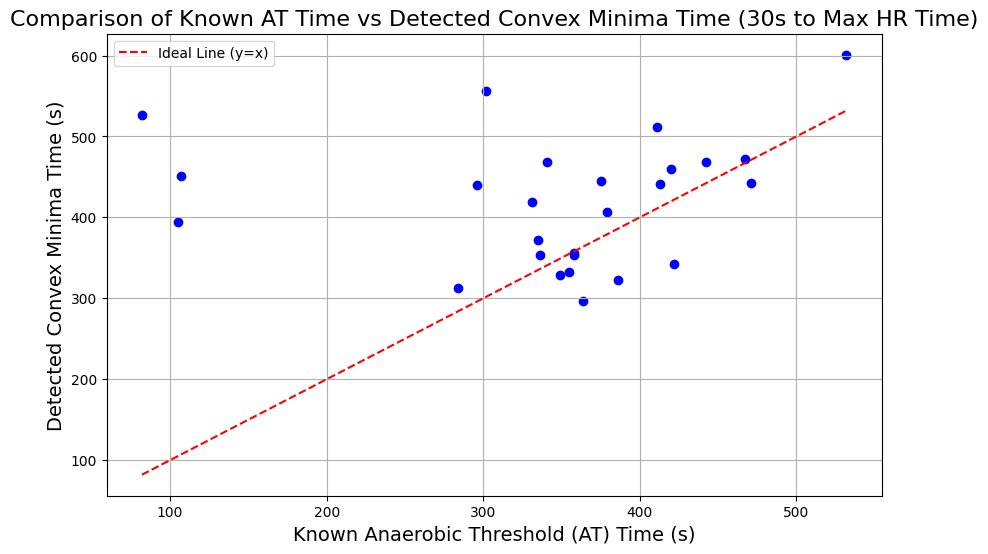

     Subject  AT_time  Convex_Minima_Time
0   001_2025    105.0               394.0
1   002_2025     82.0               527.0
2   003_2025    335.0               372.0
3   004_2025    422.0               343.0
4   005_2025    358.0               356.0
5   006_2025    379.0               407.0
6   007_2025    331.0               419.0
7   008_2025    413.0               441.0
8   009_2025    341.0               468.0
9   010_2025    386.0               323.0
10  011_2025    364.0               297.0
11  012_2025    355.0               333.0
12  013_2025    467.0               472.0
13  014_2025    442.0               469.0
14  015_2025    296.0               440.0
15  016_2025    420.0               460.0
16  017_2025    336.0               353.0
17  018_2025    349.0               329.0
18  019_2025    471.0               443.0
19  020_2025    358.0               353.0
20  021_2025    107.0               451.0
21  022_2025    411.0               512.0
22  023_2025    302.0             

In [129]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df['AT_time'] = results_df['AT_time'].astype(float)
results_df['Convex_Minima_Time'] = results_df['Convex_Minima_Time'].astype(float)

# Scatterplot of Convex Minima Time vs Known AT Time
plt.figure(figsize=(10, 6))
plt.scatter(results_df['AT_time'], results_df['Convex_Minima_Time'], color='blue')
plt.plot([results_df['AT_time'].min(), results_df['AT_time'].max()],
         [results_df['AT_time'].min(), results_df['AT_time'].max()],
         color='red', linestyle='--', label='Ideal Line (y=x)')
plt.xlabel('Known Anaerobic Threshold (AT) Time (s)', fontsize=14)
plt.ylabel('Detected Convex Minima Time (s)', fontsize=14)
plt.title('Comparison of Known AT Time vs Detected Convex Minima Time (30s to Max HR Time)', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

# Display the results
print(results_df)